In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from models.feature_selection import balance_data


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import Counter

In [3]:
df = pd.read_csv('merged_annotated_data.csv', sep=',')
df_underSampled = balance_data(df)

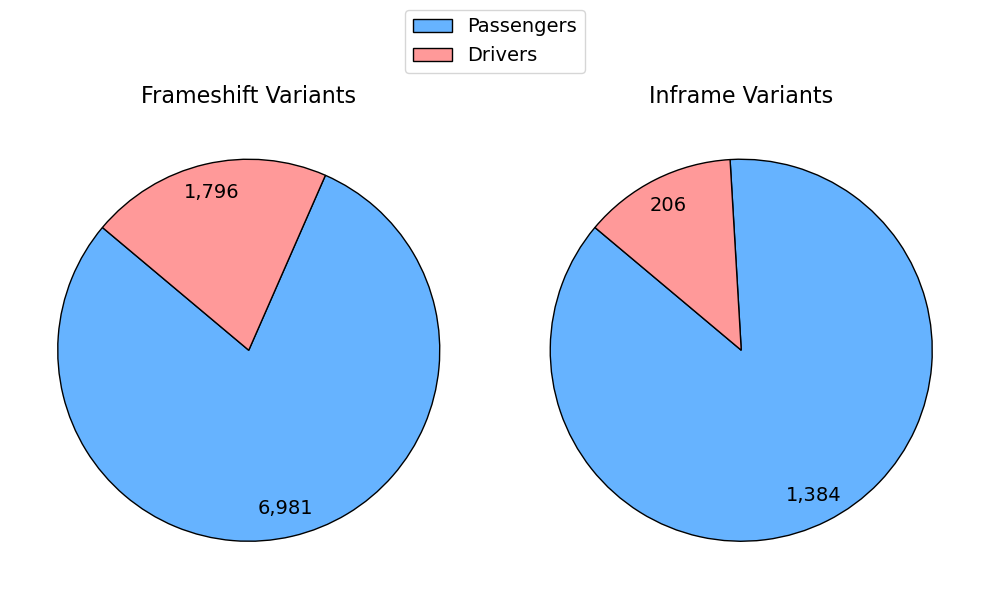

In [9]:
# inframe = pd.read_csv('data/inframe_data.csv', sep=',')
# frameshift = pd.read_csv('data/frameshift_data.csv', sep=',')
# print(inframe.shape, frameshift.shape)
# inframe['type'] = 1
# frameshift['type'] = -1

# both = pd.concat([inframe, frameshift], ignore_index=True)
# print(both.shape)

# fig, axs = plt.subplots(1, 2, figsize=(14, 7))

# # Corrected condition using bitwise operators and sum to get counts
# driver_inframe = both[(both['type'] == 1) & (both['driver_stat'] == 1)].shape[0]
# driver_frameshift = both[(both['type'] == -1) & (both['driver_stat'] == 1)].shape[0]

# pass_inframe = both[(both['type'] == 1) & (both['driver_stat'] == 0)].shape[0]
# pass_frameshift = both[(both['type'] == -1) & (both['driver_stat'] == 0)].shape[0]

# axs[0].pie([pass_frameshift, driver_frameshift], autopct=lambda p: f'{int(p * sum([driver_inframe, driver_frameshift]) / 100)}', 
#            colors=['#ff9999','#66b3ff'], startangle=140, pctdistance=0.85, wedgeprops={'edgecolor': 'black'}, textprops={'fontsize': 14})

# axs[1].pie([pass_inframe, driver_inframe], autopct=lambda p: f'{int(p * sum([pass_inframe, pass_frameshift]) / 100)}', 
#            colors=['#ff9999','#66b3ff'], startangle=140, pctdistance=0.85, wedgeprops={'edgecolor': 'black'}, 
#            textprops={'fontsize': 14})
# axs[0].set_title('Frameshift Variants', fontsize=16)
# axs[1].set_title('Inframe Variants', fontsize=16)
# fig.legend(['Passengers', 'Drivers'], loc='upper center', fontsize=14)
# fig.tight_layout()
# # plt.savefig("figs/inframe_frameshift_pies.png", dpi=300, bbox_inches='tight')
# plt.show()



# Custom label function to show raw values
def make_autonumber(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val:,}'  # adds commas to large numbers
    return my_autopct

fig, axs = plt.subplots(1, 2, figsize=(10, 7))

# Frameshift: [Passengers, Drivers]
frameshift_counts = [6981, 1796]
axs[0].pie(
    frameshift_counts,
    labels=None,
    colors=['#66b3ff', '#ff9999'],
    startangle=140,
    autopct=make_autonumber(frameshift_counts),
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 14}
)

# Inframe: [Passengers, Drivers]
inframe_counts = [1384, 206]
axs[1].pie(
    inframe_counts,
    labels=None,
    colors=['#66b3ff', '#ff9999'],
    startangle=140,
    autopct=make_autonumber(inframe_counts),
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 14}
)

# Titles and legend
axs[0].set_title('Frameshift Variants', fontsize=16)
axs[1].set_title('Inframe Variants', fontsize=16)

fig.legend(['Passengers', 'Drivers'], loc='upper center', fontsize=14)
fig.tight_layout()
plt.show()


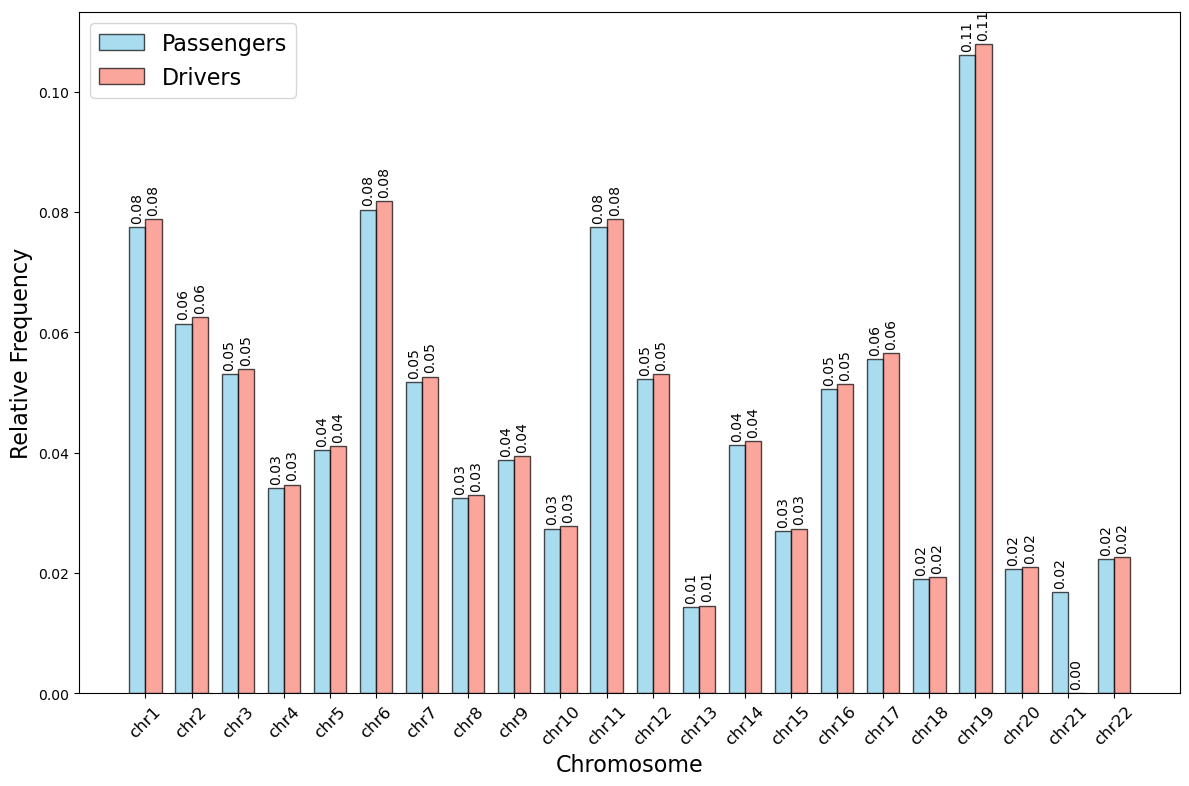

In [4]:
chrom_passenger = df_underSampled[df_underSampled['driver_stat'] == 0]
chrom_driver = df_underSampled[df_underSampled['driver_stat'] == 1]

# Count the chromosome values
passenger_dist = Counter(chrom_passenger['chrom'])
driver_dist = Counter(chrom_driver['chrom'])

# Helper function to extract numeric value from a chromosome label
def extract_number(label):
    # Remove common non-digit parts like "chr" if they exist, then convert to int.
    # Adjust the logic if your labels are different.
    return int(''.join(filter(str.isdigit, label)))

# Sort the distributions by numeric order of the chromosome labels
sorted_pass = sorted(passenger_dist.items(), key=lambda x: extract_number(x[0]))
sorted_driver = sorted(driver_dist.items(), key=lambda x: extract_number(x[0]))

# Unpack the sorted items into labels and values
labels_pass, values_pass = zip(*sorted_pass)
labels_driver, values_driver = zip(*sorted_driver)

# fig, axs = plt.subplots(1, 2, figsize=(14, 7))

# # Pie chart for passengers
# # labels_pass = list(passenger_dist.keys())
# # sizes_pass = list(passenger_dist.values())
# axs[0].pie(values_pass, labels=labels_pass, autopct='%1.1f%%', startangle=90,pctdistance=0.8)
# axs[0].set_title("Chromosome Distribution for Passengers")

# # Pie chart for drivers
# # labels_driver = list(driver_dist.keys())
# # sizes_driver = list(driver_dist.values())
# axs[1].pie(values_driver, labels=labels_driver, autopct='%1.1f%%', startangle=90, pctdistance=0.8)
# axs[1].set_title("Chromosome Distribution for Drivers")
# plt.tight_layout()
# plt.show()


labels = sorted(set(labels_pass) | set(labels_driver), key=extract_number)

# Create dictionaries for quick lookup of counts
pass_dict = dict(sorted_pass)
driver_dict = dict(sorted_driver)

# Compute normalized distributions (i.e. relative frequencies)
total_pass = sum(pass_dict.values())
total_driver = sum(driver_dict.values())

norm_pass = [pass_dict.get(label, 0) / total_pass for label in labels]
norm_driver = [driver_dict.get(label, 0) / total_driver for label in labels]

# Plot both distributions on the same axes.
fig, ax = plt.subplots(figsize=(12, 8))

bar_width = 0.35
x = range(len(labels))

# Plotting the bars
bars1 = ax.bar([i - bar_width/2 for i in x], norm_pass, width=bar_width, 
                        color='skyblue', label='Passengers', alpha=0.7, edgecolor='black')
bars2 = ax.bar([i + bar_width/2 for i in x], norm_driver, width=bar_width, 
                        color='salmon', label='Drivers', alpha=0.7, edgecolor='black')

# Adding labels, title, and legend
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, fontsize=12)
ax.set_xlabel("Chromosome", fontsize=16)
ax.set_ylabel("Relative Frequency", fontsize=16)
# ax.set_title("Chromosome Distribution (Relative Frequency) for Passengers & Drivers", fontsize=16)
ax.legend(fontsize=16)

# Adding value labels on top of the bars
def add_value_labels(bars):
       for bar in bars:
              height = bar.get_height()
              ax.annotate(f'{height:.2f}', 
                                   xy=(bar.get_x() + bar.get_width() / 2, height),
                                   xytext=(0, 3),  # 3 points vertical offset
                                   textcoords="offset points",
                                   ha='center', va='bottom', fontsize=10, rotation=90)

add_value_labels(bars1)
add_value_labels(bars2)



plt.tight_layout()
plt.show()

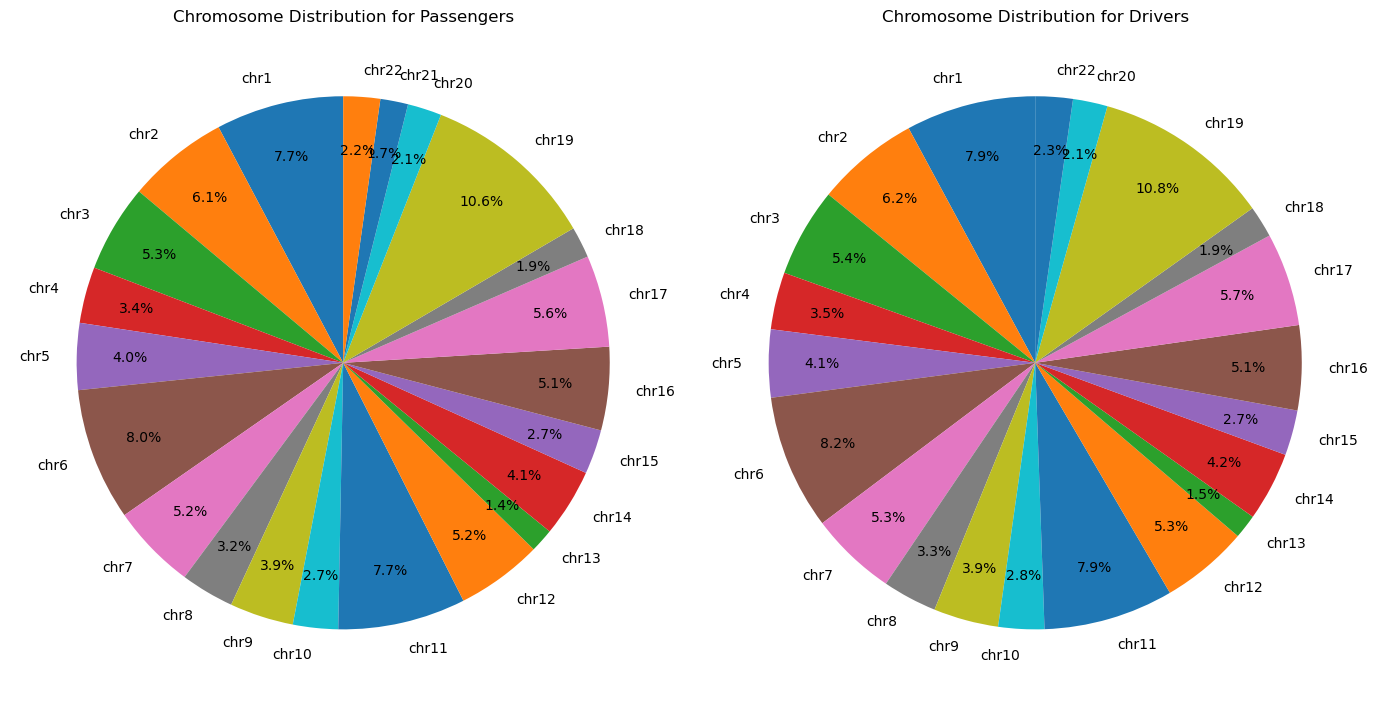

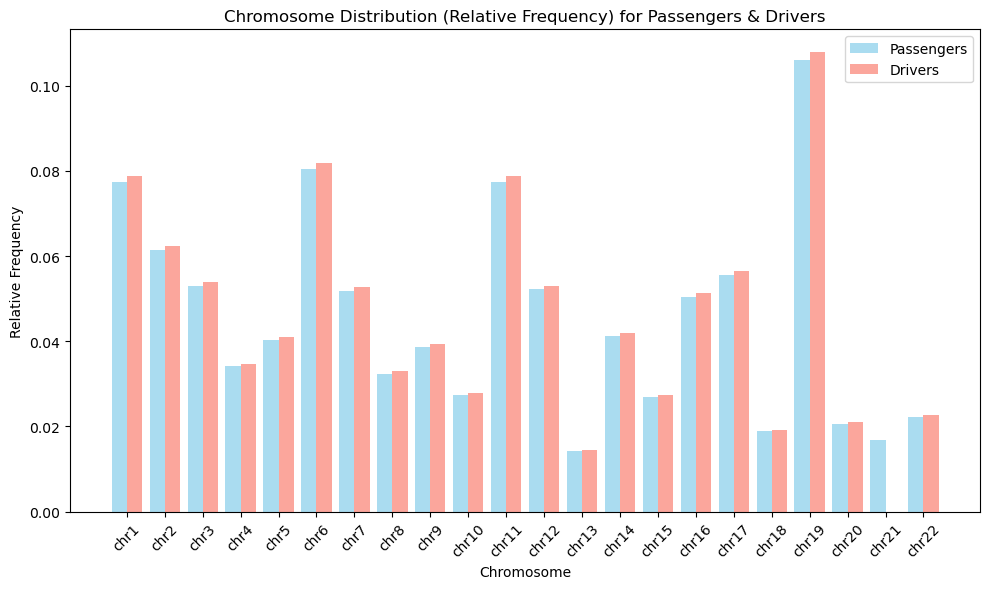

In [7]:
chrom_passenger = df_underSampled[df_underSampled['driver_stat'] == 0]
chrom_driver = df_underSampled[df_underSampled['driver_stat'] == 1]

# Count the chromosome values
passenger_dist = Counter(chrom_passenger['chrom'])
driver_dist = Counter(chrom_driver['chrom'])

# Helper function to extract numeric value from a chromosome label
def extract_number(label):
    # Remove common non-digit parts like "chr" if they exist, then convert to int.
    # Adjust the logic if your labels are different.
    return int(''.join(filter(str.isdigit, label)))

# Sort the distributions by numeric order of the chromosome labels
sorted_pass = sorted(passenger_dist.items(), key=lambda x: extract_number(x[0]))
sorted_driver = sorted(driver_dist.items(), key=lambda x: extract_number(x[0]))

# Unpack the sorted items into labels and values
labels_pass, values_pass = zip(*sorted_pass)
labels_driver, values_driver = zip(*sorted_driver)

fig, axs = plt.subplots(1, 2, figsize=(14, 7))

# Pie chart for passengers
# labels_pass = list(passenger_dist.keys())
# sizes_pass = list(passenger_dist.values())
axs[0].pie(values_pass, labels=labels_pass, autopct='%1.1f%%', startangle=90,pctdistance=0.8)
axs[0].set_title("Chromosome Distribution for Passengers")

# Pie chart for drivers
# labels_driver = list(driver_dist.keys())
# sizes_driver = list(driver_dist.values())
axs[1].pie(values_driver, labels=labels_driver, autopct='%1.1f%%', startangle=90, pctdistance=0.8)
axs[1].set_title("Chromosome Distribution for Drivers")
plt.tight_layout()
plt.show()

#BAR CHARTS

labels = sorted(set(labels_pass) | set(labels_driver), key=extract_number)

# Create dictionaries for quick lookup of counts
pass_dict = dict(sorted_pass)
driver_dict = dict(sorted_driver)

# Compute normalized distributions (i.e. relative frequencies)
total_pass = sum(pass_dict.values())
total_driver = sum(driver_dict.values())

norm_pass = [pass_dict.get(label, 0) / total_pass for label in labels]
norm_driver = [driver_dict.get(label, 0) / total_driver for label in labels]

# Plot both distributions on the same axes.
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.4
x = range(len(labels))

ax.bar([i - bar_width/2 for i in x], norm_pass, width=bar_width, 
       color='skyblue', label='Passengers', alpha=0.7)
ax.bar([i + bar_width/2 for i in x], norm_driver, width=bar_width, 
       color='salmon', label='Drivers', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel("Chromosome")
ax.set_ylabel("Relative Frequency")
ax.set_title("Chromosome Distribution (Relative Frequency) for Passengers & Drivers")
ax.legend()

plt.tight_layout()
plt.show()


In [15]:
cons_features = ['phyloP20way','k36.Bismap.MultiTrackMappability','k50.Bismap.MultiTrackMappability',
                 'phyloP30way','phyloP17way','phyloP100way','phastCons470way','k24.Umap.MultiTrackMappability',
                 'phyloP7way','phastCons20way','k100.Umap.MultiTrackMappability','phyloP470way','k50.Umap.MultiTrackMappability',
                 'phastCons100way','phastCons17way','phastCons30way','k36.Umap.MultiTrackMappability','phastCons7way',
                 'k24.Bismap.MultiTrackMappability','k100.Bismap.MultiTrackMappability','phyloP4way','phastCons4way'
            ]

dna_shape = [
    '3_MGW', '4_MGW', '5_MGW', '6_MGW', '7_MGW', '8_MGW', '9_MGW', '10_MGW', '11_MGW', '12_MGW', 
    '13_MGW', '14_MGW', '15_MGW', '16_MGW', '17_MGW', '18_MGW', '2_HelT', '3_HelT', '4_HelT', '5_HelT', 
    '6_HelT', '7_HelT', '8_HelT', '9_HelT', '10_HelT', '11_HelT', '12_HelT', '13_HelT', '14_HelT', 
    '15_HelT', '16_HelT', '17_HelT', '18_HelT', '3_ProT', '4_ProT', '5_ProT', '6_ProT', '7_ProT', 
    '8_ProT', '9_ProT', '10_ProT', '11_ProT', '12_ProT', '13_ProT', '14_ProT', '15_ProT', '16_ProT', 
    '17_ProT', '18_ProT', '2_Roll_x', '3_Roll_x', '4_Roll_x', '5_Roll', '6_Roll', '7_Roll', '8_Roll', 
    '9_Roll', '10_Roll', '11_Roll', '12_Roll', '13_Roll', '14_Roll', '15_Roll', '16_Roll', '17_Roll', 
    '18_Roll', '3_EP', '4_EP', '5_EP', '6_EP', '7_EP', '8_EP', '9_EP', '10_EP', '11_EP', '12_EP', 
    '13_EP', '14_EP', '15_EP', '16_EP', '17_EP', '18_EP'
]

dna_props = [
    'WTtrinuc', 'mutTrinuc', '1_Bend', '1_Tip', '1_Inclination', '1_Major_Groove_Width', '1_Major_Groove_Depth',
    '1_Major_Groove_Size', '1_Major_Groove_Distance', '1_Minor_Groove_Width', '1_Minor_Groove_Depth',
    '1_Minor_Groove_Size', '1_Minor_Groove_Distance', '1_Persistance_Length',
    '1_Probability_contacting_nucleosome_core', '1_Mobility_to_bend_towards_major_groove',
    '1_Mobility_to_bend_towards_minor_groove', '1_Propeller_Twist', '1_Clash_Strength', '1_Shift_(RNA)',
    '1_Hydrophilicity_(RNA)', '1_Twist_(DNA-protein_complex)', '1_Twist_twist', '1_Tilt_tilt', '1_Roll_roll',
    '1_Twist_tilt', '1_Twist_roll', '1_Tilt_roll', '1_Shift_shift', '1_Slide_slide', '1_Rise_rise',
    '1_Shift_slide', '1_Shift_rise', '1_Slide_rise', '1_Twist_shift', '1_Twist_slide', '1_Twist_rise',
    '1_Tilt_shift', '1_Tilt_slide', '1_Tilt_rise', '1_Roll_shift', '1_Roll_slide', '1_Roll_rise',
    '1_Slide_stiffness', '1_Shift_stiffness', '1_Roll_stiffness', '1_Tilt_stiffness', '1_Twist_stiffness',
    '1_GC_content', '1_Purine_(AG)_content', '1_Keto_(GT)_content', '1_Adenine_content', '1_Guanine_content',
    '1_Cytosine_content', '1_Thymine_content', '1_Tilt_(DNA-protein_complex)', '1_Roll_(DNA-protein_complex)',
    '1_Shift_(DNA-protein_complex)', '1_Slide_(DNA-protein_complex)', '1_Rise_(DNA-protein_complex)', '1_Shift',
    '1_Slide', '1_Rise', '1_Wedge', '1_Direction', '1_Slide_(RNA)', '1_Rise_(RNA)', '1_Tilt_(RNA)',
    '1_Roll_(RNA)', '1_Twist_(RNA)', '1_Stacking_energy_(RNA)', '1_Rise_stiffness', '1_Melting_Temperature',
    '1_Stacking_energy', '1_Free_energy_(RNA)', '1_Enthalpy_(RNA)', '1_Entropy_(RNA)', '1_Tilt', '1_Roll',
    '1_Twist', '1_Flexibility_slide', '1_Flexibility_shift', '1_Enthalpy', '1_Entropy', '1_Free_energy',
    '2_Bend', '2_Tip', '2_Inclination', '2_Major_Groove_Width', '2_Major_Groove_Depth', '2_Major_Groove_Size',
    '2_Major_Groove_Distance', '2_Minor_Groove_Width', '2_Minor_Groove_Depth', '2_Minor_Groove_Size',
    '2_Minor_Groove_Distance', '2_Persistance_Length',
    '2_Probability_contacting_nucleosome_core', '2_Mobility_to_bend_towards_major_groove',
    '2_Mobility_to_bend_towards_minor_groove', '2_Propeller_Twist', '2_Clash_Strength', '2_Shift_(RNA)',
    '2_Hydrophilicity_(RNA)', '2_Twist_(DNA-protein_complex)', '2_Twist_twist', '2_Tilt_tilt', '2_Roll_roll',
    '2_Twist_tilt', '2_Twist_roll', '2_Tilt_roll', '2_Shift_shift', '2_Slide_slide', '2_Rise_rise',
    '2_Shift_slide', '2_Shift_rise', '2_Slide_rise', '2_Twist_shift', '2_Twist_slide', '2_Twist_rise',
    '2_Tilt_shift', '2_Tilt_slide', '2_Tilt_rise', '2_Roll_shift', '2_Roll_slide', '2_Roll_rise',
    '2_Slide_stiffness', '2_Shift_stiffness', '2_Roll_stiffness', '2_Tilt_stiffness', '2_Twist_stiffness',
    '2_GC_content', '2_Purine_(AG)_content', '2_Keto_(GT)_content', '2_Adenine_content', '2_Guanine_content',
    '2_Cytosine_content', '2_Thymine_content', '2_Tilt_(DNA-protein_complex)', '2_Roll_(DNA-protein_complex)',
    '2_Shift_(DNA-protein_complex)', '2_Slide_(DNA-protein_complex)', '2_Rise_(DNA-protein_complex)', '2_Shift',
    '2_Slide', '2_Rise', '2_Wedge', '2_Direction', '2_Slide_(RNA)', '2_Rise_(RNA)', '2_Tilt_(RNA)',
    '2_Roll_(RNA)', '2_Twist_(RNA)', '2_Stacking_energy_(RNA)', '2_Rise_stiffness', '2_Melting_Temperature',
    '2_Stacking_energy', '2_Free_energy_(RNA)', '2_Enthalpy_(RNA)', '2_Entropy_(RNA)', '2_Tilt', '2_Roll_y',
    '2_Twist', '2_Flexibility_slide', '2_Flexibility_shift', '2_Enthalpy', '2_Entropy', '2_Free_energy',
    '3_Bend', '3_Tip', '3_Inclination', '3_Major_Groove_Width', '3_Major_Groove_Depth', '3_Major_Groove_Size',
    '3_Major_Groove_Distance', '3_Minor_Groove_Width', '3_Minor_Groove_Depth', '3_Minor_Groove_Size',
    '3_Minor_Groove_Distance', '3_Persistance_Length', '3_Probability_contacting_nucleosome_core',
    '3_Mobility_to_bend_towards_major_groove', '3_Mobility_to_bend_towards_minor_groove', '3_Propeller_Twist',
    '3_Clash_Strength', '3_Shift_(RNA)', '3_Hydrophilicity_(RNA)', '3_Twist_(DNA-protein_complex)',
    '3_Twist_twist', '3_Tilt_tilt', '3_Roll_roll', '3_Twist_tilt', '3_Twist_roll', '3_Tilt_roll',
    '3_Shift_shift', '3_Slide_slide', '3_Rise_rise', '3_Shift_slide', '3_Shift_rise', '3_Slide_rise',
    '3_Twist_shift', '3_Twist_slide', '3_Twist_rise', '3_Tilt_shift', '3_Tilt_slide', '3_Tilt_rise',
    '3_Roll_shift', '3_Roll_slide', '3_Roll_rise', '3_Slide_stiffness', '3_Shift_stiffness', '3_Roll_stiffness',
    '3_Tilt_stiffness', '3_Twist_stiffness', '3_GC_content', '3_Purine_(AG)_content', '3_Keto_(GT)_content',
    '3_Adenine_content', '3_Guanine_content', '3_Cytosine_content', '3_Thymine_content',
    '3_Tilt_(DNA-protein_complex)', '3_Roll_(DNA-protein_complex)', '3_Shift_(DNA-protein_complex)',
    '3_Slide_(DNA-protein_complex)', '3_Rise_(DNA-protein_complex)', '3_Shift', '3_Slide', '3_Rise',
    '3_Wedge', '3_Direction', '3_Slide_(RNA)', '3_Rise_(RNA)', '3_Tilt_(RNA)', '3_Roll_(RNA)', '3_Twist_(RNA)',
    '3_Stacking_energy_(RNA)', '3_Rise_stiffness', '3_Melting_Temperature', '3_Stacking_energy',
    '3_Free_energy_(RNA)', '3_Enthalpy_(RNA)', '3_Entropy_(RNA)', '3_Tilt', '3_Roll_y', '3_Twist',
    '3_Flexibility_slide', '3_Flexibility_shift', '3_Enthalpy', '3_Entropy', '3_Free_energy',
    '4_Bend', '4_Tip', '4_Inclination', '4_Major_Groove_Width', '4_Major_Groove_Depth', '4_Major_Groove_Size',
    '4_Major_Groove_Distance', '4_Minor_Groove_Width', '4_Minor_Groove_Depth', '4_Minor_Groove_Size',
    '4_Minor_Groove_Distance', '4_Persistance_Length', '4_Probability_contacting_nucleosome_core',
    '4_Mobility_to_bend_towards_major_groove', '4_Mobility_to_bend_towards_minor_groove', '4_Propeller_Twist',
    '4_Clash_Strength', '4_Shift_(RNA)', '4_Hydrophilicity_(RNA)', '4_Twist_(DNA-protein_complex)',
    '4_Twist_twist', '4_Tilt_tilt', '4_Roll_roll', '4_Twist_tilt', '4_Twist_roll', '4_Tilt_roll',
    '4_Shift_shift', '4_Slide_slide', '4_Rise_rise', '4_Shift_slide', '4_Shift_rise', '4_Slide_rise',
    '4_Twist_shift', '4_Twist_slide', '4_Twist_rise', '4_Tilt_shift', '4_Tilt_slide', '4_Tilt_rise',
    '4_Roll_shift', '4_Roll_slide', '4_Roll_rise', '4_Slide_stiffness', '4_Shift_stiffness', '4_Roll_stiffness',
    '4_Tilt_stiffness', '4_Twist_stiffness', '4_GC_content', '4_Purine_(AG)_content', '4_Keto_(GT)_content',
    '4_Adenine_content', '4_Guanine_content', '4_Cytosine_content', '4_Thymine_content',
    '4_Tilt_(DNA-protein_complex)', '4_Roll_(DNA-protein_complex)', '4_Shift_(DNA-protein_complex)',
    '4_Slide_(DNA-protein_complex)', '4_Rise_(DNA-protein_complex)', '4_Shift', '4_Slide', '4_Rise', '4_Wedge',
    '4_Direction', '4_Slide_(RNA)', '4_Rise_(RNA)', '4_Tilt_(RNA)', '4_Roll_(RNA)', '4_Twist_(RNA)',
    '4_Stacking_energy_(RNA)', '4_Rise_stiffness', '4_Melting_Temperature', '4_Stacking_energy',
    '4_Free_energy_(RNA)', '4_Enthalpy_(RNA)', '4_Entropy_(RNA)', '4_Tilt', '4_Roll_y', '4_Twist',
    '4_Flexibility_slide', '4_Flexibility_shift', '4_Enthalpy', '4_Entropy', '4_Free_energy'
]


alphaFold = ['X_coordinate','Y_coordinate','Z_coordinate','atom_site_occupancy','isotropic_temperature']

gcConent = [
    '20GCContent', '20CpGCount', '20CpG_obs_exp',
    '40GCContent', '40CpGCount', '40CpG_obs_exp',
    '60GCContent', '60CpGCount', '60CpG_obs_exp',
    '80GCContent', '80CpGCount', '80CpG_obs_exp',
    '100GCContent', '100CpGCount', '100CpG_obs_exp',
    '200GCContent', '200CpGCount', '200CpG_obs_exp',
    '500GCContent', '500CpGCount', '500CpG_obs_exp',
    '1000GCContent', '1000CpGCount', '1000CpG_obs_exp',
    '2000GCContent', '2000CpGCount', '2000CpG_obs_exp'
]

pmed = ['PubMed']


features = {'Conservation': len(cons_features),
            'DNA Shape': len(dna_shape),
            'PubMed': len(pmed),
            'DNA Properties': len(dna_props),
            'GC Content': len(gcConent),
            
            'AlphaFold2': len(alphaFold),
            
            }

print(features)

{'Conservation': 22, 'DNA Shape': 82, 'PubMed': 1, 'DNA Properties': 334, 'GC Content': 27, 'AlphaFold2': 5}


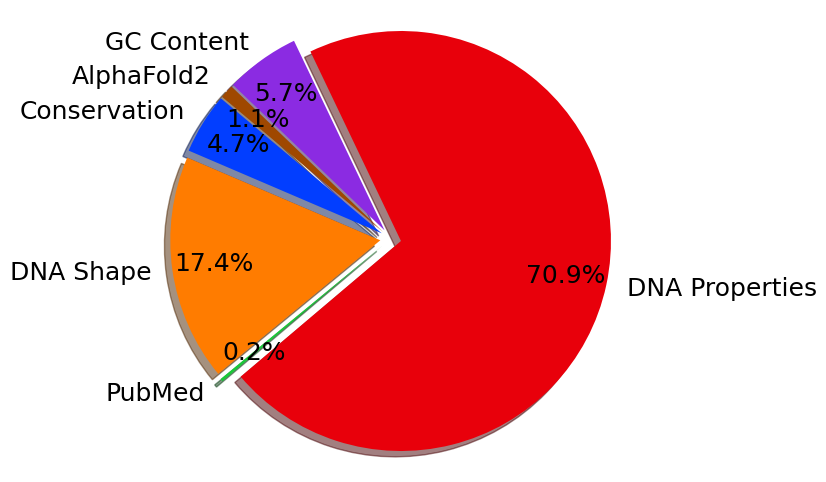

In [26]:
labels = list(features.keys())
values = list(features.values())

# Define a color palette
colors = sns.color_palette('bright')[0:len(labels)]

# Define explode values to slightly separate the slices
explode = [0.05] * len(labels)

plt.figure(figsize=(7, 6))  # Set the figure size to 10x10 inches
plt.pie(values, labels=labels, startangle=140, autopct='%1.1f%%', pctdistance=0.8, colors=colors, explode=explode, shadow=True, textprops={'fontsize': 18})
plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.show()

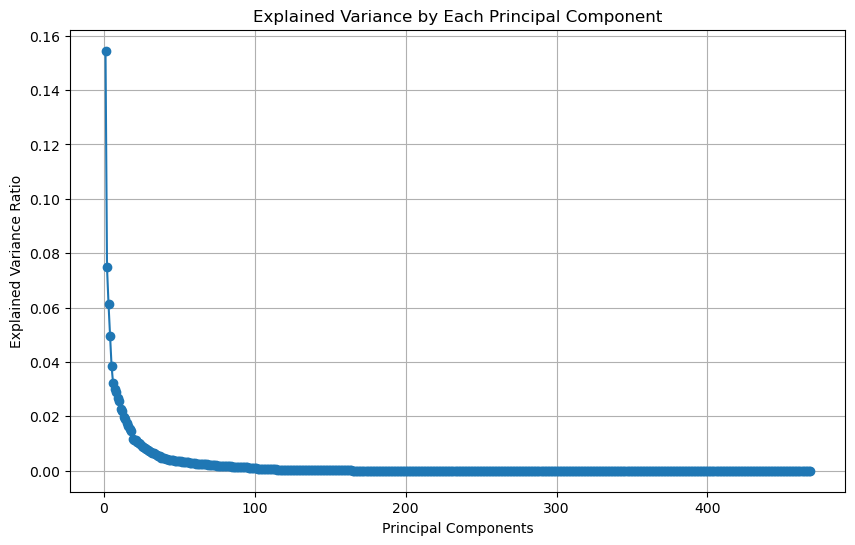

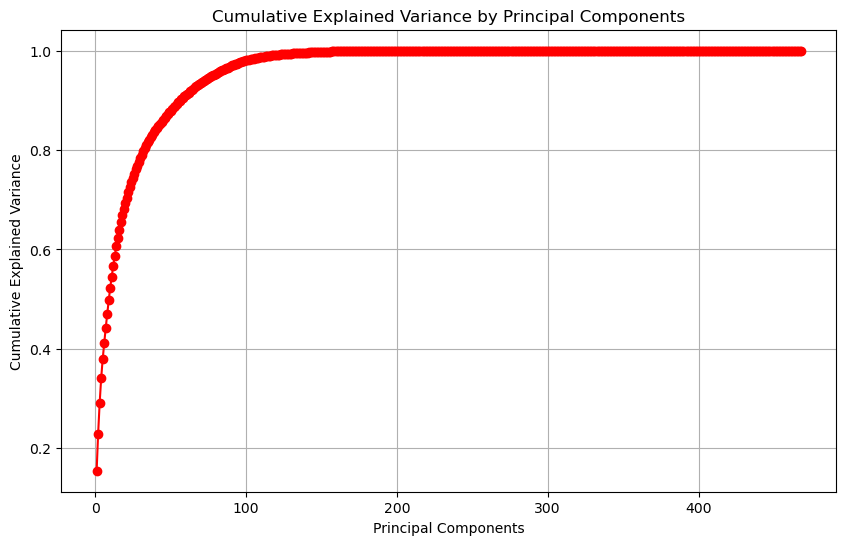

Number of components explaining at least 90% variance: 57
(13393, 57)
Number of components explaining at least 90% variance: 57
Reduced shape: (13393, 57)
      phyloP20way  k36.Bismap.MultiTrackMappability  \
PC1     -0.007566                         -0.000999   
PC2      0.002244                          0.000610   
PC3     -0.000006                         -0.001375   
PC4      0.013051                          0.013472   
PC5     -0.014263                         -0.006070   
PC6     -0.002356                         -0.005097   
PC7     -0.008608                         -0.005947   
PC8     -0.020162                         -0.019491   
PC9     -0.013252                         -0.008162   
PC10     0.011716                          0.003874   
PC11     0.131369                          0.087956   
PC12     0.185512                          0.105786   
PC13    -0.075299                         -0.041824   
PC14     0.025969                          0.019902   
PC15     0.001748   

In [ ]:
# Drop non-numeric columns and target
X = df.drop(columns=['chrom', 'pos', 'ref_allele', 'alt_allele', 'driver_stat', 'merged', 'WTtrinuc', 'mutTrinuc'])  # Adjust according to your data
y = df['driver_stat']

# Handling missing values (if any)
X = X.fillna(X.mean())  # Fill with the mean, you can also try other methods

# Standardize the features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained Variance Ratio - This shows how much information each principal component holds
explained_variance_ratio = pca.explained_variance_ratio_

# Visualize the explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.title("Explained Variance by Each Principal Component")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

# Cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', color='r')
plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()


# Project the data onto the first 2 principal components for visualization
X_pca_2d = X_pca[:, :2]

# Create a DataFrame for visualization
pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
pca_df['driver_stat'] = y  # Add target variable to color points


# Number of components to retain for 90% explained variance
n_components = np.argmax(cumulative_explained_variance >= 0.90) + 1
print(f"Number of components explaining at least 90% variance: {n_components}")



# Apply PCA again, keeping the chosen number of components
pca = PCA(n_components=n_components)
X_pca_reduced = pca.fit_transform(X_scaled)
print(X_pca_reduced.shape)

# Number of components to retain for 90% explained variance
n_components = np.argmax(cumulative_explained_variance >= 0.90) + 1
print(f"Number of components explaining at least 90% variance: {n_components}")

# Apply PCA again, keeping the chosen number of components
pca = PCA(n_components=n_components)
X_pca_reduced = pca.fit_transform(X_scaled)
print("Reduced shape:", X_pca_reduced.shape)

# The components_ attribute is a matrix of shape (n_components, n_features)
# Each row corresponds to a principal component and each column to an original feature.
# We can inspect these loadings to see which features contribute most to each PC.
loadings = pca.components_

# Create a DataFrame for the loadings with feature names as columns
loading_df = pd.DataFrame(loadings, columns=X.columns)
loading_df.index = [f'PC{i+1}' for i in range(n_components)]
print(loading_df)

# For each principal component, you might want to extract the top contributing features.
# For example, to get the top 5 features for each component:
top_features = {}
for pc in loading_df.index:
    # Get absolute values of loadings for current PC and sort descending
    sorted_features = loading_df.loc[pc].abs().sort_values(ascending=False)
    top_features[pc] = sorted_features.head(5).index.tolist()

print("Top contributing features for each principal component:")
for pc, features in top_features.items():
    print(f"{pc}: {features}")



In [ ]:
sset = set()
for pc, ls in top_features.items():
    sset.update(ls)

ls = list(sset)


['17_ProT',
 '2_Clash_Strength',
 '3_Twist_shift',
 '1_Adenine_content',
 '12_Roll',
 'phastCons30way',
 '2_HelT',
 '2_Twist_tilt',
 '1_Twist_rise',
 '2_GC_content',
 '16_HelT',
 '13_MGW',
 '4_Twist_rise',
 '1_Rise_(RNA)',
 'k50.Bismap.MultiTrackMappability',
 '15_HelT',
 '1_Roll_slide',
 '4_Shift',
 '4_Shift_stiffness',
 '2_Twist_rise',
 '1_Minor_Groove_Size',
 '3_Enthalpy',
 '1_Hydrophilicity_(RNA)',
 '3_MGW',
 '14_HelT',
 '1_Major_Groove_Size',
 '1_Shift_(RNA)',
 '1_Tilt_rise',
 '3_Probability_contacting_nucleosome_core',
 '1_Shift_rise',
 '17_MGW',
 '18_MGW',
 '3_Hydrophilicity_(RNA)',
 '1_Roll_shift',
 '7_ProT',
 '2_Purine_(AG)_content',
 '1_GC_content',
 '2_Propeller_Twist',
 '3_Purine_(AG)_content',
 '10_ProT',
 '2_Shift_(RNA)',
 'phyloP20way',
 '6_ProT',
 '4_Tilt_stiffness',
 '12_EP',
 '6_Roll',
 '3_GC_content',
 '1_Wedge',
 '13_EP',
 '2_Tilt_(RNA)',
 '5_Roll',
 '3_Entropy',
 '1_Major_Groove_Distance',
 '4_Twist_tilt',
 '13_Roll',
 'phastCons470way',
 '1_Rise_stiffness',
 '3_Sh